In [2]:
import numpy as np
import pandas as pd
import seaborn as sns 
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv("netflix_titles.csv")

In [5]:
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [6]:
df.shape

(8807, 12)

In [9]:
df.isnull().sum()


show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

In [15]:
for column in df.columns:
    percentage = df[column].isnull().mean()
    print(column + " : "+str(round(percentage*100,2)))

show_id : 0.0
type : 0.0
title : 0.0
director : 29.91
cast : 9.37
country : 9.44
date_added : 0.11
release_year : 0.0
rating : 0.05
duration : 0.03
listed_in : 0.0
description : 0.0


In [13]:
df["director"]=df["director"].fillna("Unknown")
df["cast"]=df["cast"].fillna("Unknown")
df["country"]=df["country"].fillna("Unknown")
df["date_added"]=df["date_added"].fillna("Unknown")
df['rating'] = df['rating'].fillna(df['rating'].mode()[0])

In [14]:
df.isnull().sum()


show_id         0
type            0
title           0
director        0
cast            0
country         0
date_added      0
release_year    0
rating          0
duration        3
listed_in       0
description     0
dtype: int64

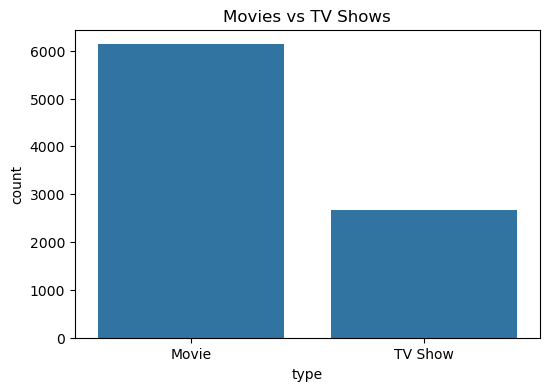

In [15]:
# -------------------------------
# 1 Movies vs TV Shows
# -------------------------------
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='type')
plt.title("Movies vs TV Shows")
plt.show()

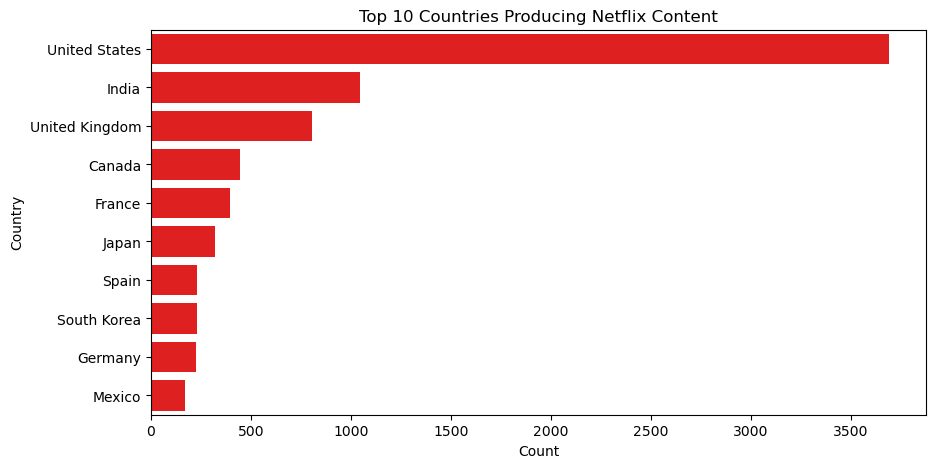

In [18]:

countries = df['country'].str.split(', ', expand=True).stack()

top_countries = countries.value_counts().head(10)

plt.figure(figsize=(10,5))
sns.barplot(x=top_countries.values, y=top_countries.index , color="red")

plt.title("Top 10 Countries Producing Netflix Content")
plt.xlabel("Count")
plt.ylabel("Country")
plt.show()

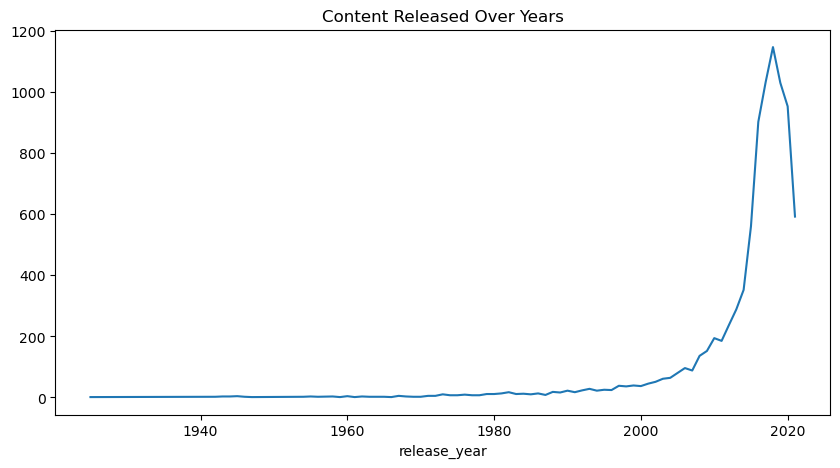

In [16]:
plt.figure(figsize=(10,5))
df['release_year'].value_counts().sort_index().plot()
plt.title("Content Released Over Years")
plt.show()

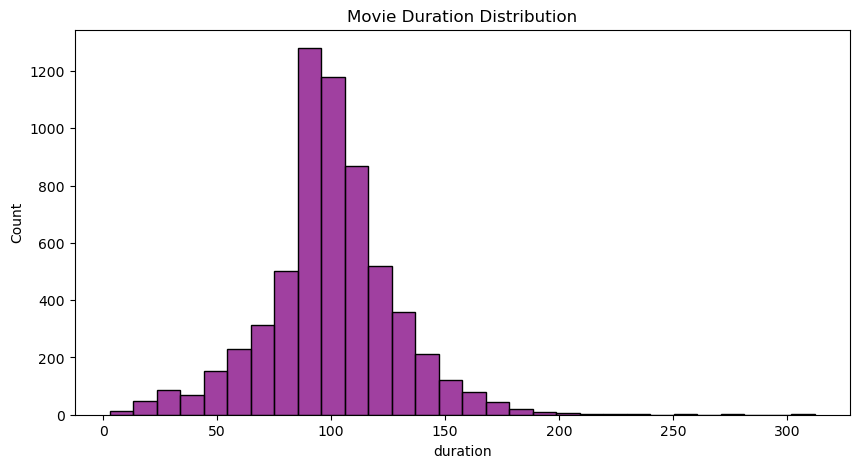

In [32]:
movies = df[df['type'] == 'Movie'].copy()
movies['duration'] = movies['duration'].str.replace(' min','')
movies['duration'] = pd.to_numeric(movies['duration'], errors='coerce')

plt.figure(figsize=(10,5))
sns.histplot(movies['duration'].dropna(), bins=30, color="purple")
plt.title("Movie Duration Distribution")
plt.show()


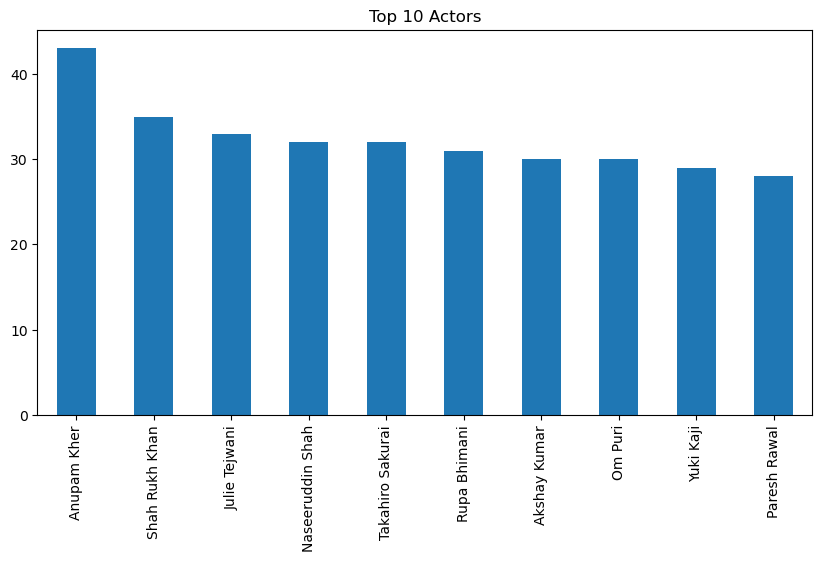

In [24]:
actors = df['cast'].str.split(', ', expand=True).stack().value_counts().head(10)

plt.figure(figsize=(10,5))
actors.plot(kind='bar')
plt.title("Top 10 Actors")
plt.show()

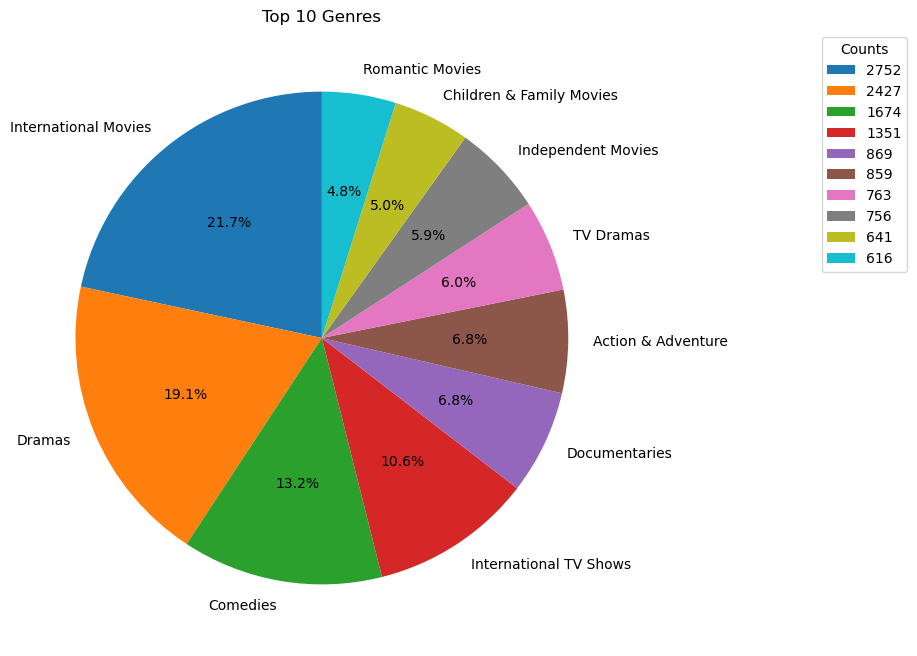

In [38]:
plt.figure(figsize=(10,8))
genres.plot(
    kind='pie',
    autopct='%1.1f%%',
    startangle=90
)
plt.legend(genres.values, title="Counts", bbox_to_anchor=(1.30, 1),
    loc='upper left')
plt.title("Top 10 Genres")
plt.ylabel('')

plt.show()